In [ ]:
# -*- coding: utf-8 -*-
# Author  : Ethan Huang
# File    : Coarse Grained.ipynb
# Time    : 2026/3/25

"""
Implementation of Ertl's Functional Group Algorithm in RDKit
(adapted for Jupyter Notebook visualization)

References:

[1] Ertl, Peter. An algorithm to identify functional groups in organic molecules  
    J Cheminform (2017) 9:36; DOI: 10.1186/s13321-017-0225-z  

[2] Colmenarejo, Gonzalo. EFGs: A Complete and Accurate Implementation of Ertl’s Functional Group Detection Algorithm in RDKit  
    J Chem Inf Model (2025) 65:1061–1066; DOI: 10.1021/acs.jcim.4c02268
"""

In [1]:
from rdkit import Chem
import re
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import Image, display  # For Jupyter visualization
from PIL import Image as PILImage
import io

In [ ]:
### Block 1: Pseudocanonicalization and carbon valence correction helpers

In [3]:
def psmi_can(s):
    """Generate canonical pseudosmiles from pseudosmiles."""
    s = s.replace("[R]", "[Ge]").replace("[Car]", "[Pb]").replace("[Cal]", "[Sn]").replace("[Oar]", "[Po]").replace("[Nar]", "[Sb]").replace("[Sar]", "[Re]")
    s = s.replace("[Nar+]", "[Sb+]").replace("[Sar+]", "[Re+]").replace("[Sear]", "[Bi]").replace("[Tear]", "[Tl]").replace("[Oar+]", "[Po+]").replace("[Nar+]", "[Sb+]")
    s = s.replace("[Nar-]", "[Sb-]").replace("[Sar+]", "[Re+]").replace("[Sar-]", "[Re-]").replace("[Sear+]", "[Bi+]").replace("[Sear-]", "[Bi-]")
    mol = Chem.MolFromSmiles(s)
    s = Chem.MolToSmiles(mol, canonical=True, isomericSmiles=False)
    s = s.replace("[Ge]", "[R]").replace("[Pb]", "[Car]").replace("[Sn]", "[Cal]").replace("[Po]", "[Oar]").replace("[Sb]", "[Nar]").replace("[Re]", "[Sar]")
    s = s.replace("[Sb+]", "[Nar+]").replace("[Re+]", "[Sar+]").replace("[Bi]", "[Sear]").replace("[Tl]", "[Tear]").replace("[Po+]", "[Oar+]").replace("[Sb+]", "[Nar+]")
    s = s.replace("[Nar-]", "[Sb-]").replace("[Re+]", "[Sar+]").replace("[Re-]", "[Sar-]").replace("[Bi+]", "[Sear+]").replace("[Bi-]", "[Sear-]")
    return s


def cval_fix(fragment):
    """Fix valences of carbons."""
    for atom in fragment.GetAtoms():
        if atom.GetSymbol() == 'C':
            charge = atom.GetFormalCharge()
            num_bonds = sum([bond.GetBondTypeAsDouble() for bond in atom.GetBonds()])
            implicit_h = atom.GetNumImplicitHs()
            explicit_h = atom.GetNumExplicitHs()
            total_valence = num_bonds + implicit_h + explicit_h
            if charge == 0:
                if total_valence != 4:
                    explicit_h = 4 - num_bonds - implicit_h
                    atom.SetNumExplicitHs(int(explicit_h))
            else:
                explicit_h = 4 - num_bonds - implicit_h + charge
                atom.SetNumExplicitHs(int(explicit_h))
            atom.UpdatePropertyCache()
    return fragment


def merge(mol, marked, aset):
    """Merge initially marked atoms into FGs."""
    bset = set()
    for idx in aset:
        atom = mol.GetAtomWithIdx(idx)
        for nbr in atom.GetNeighbors():
            jdx = nbr.GetIdx()
            if jdx in marked:
                marked.remove(jdx)
                bset.add(jdx)
    if not bset:
        return
    merge(mol, marked, bset)
    aset.update(bset)

In [5]:
### Block 2: Initial functional group detection

In [7]:
def get_fgs(mol):
    """Generate nondecorated FGs."""
    het23c_pattern = Chem.MolFromSmarts('A=,#[!#6]')
    c23c_pattern = Chem.MolFromSmarts('C=,#[C,c]')
    acetal_pattern = Chem.MolFromSmarts('[CX4](-[O,N,S])-[O,N,S]')
    oxirane_pattern = Chem.MolFromSmarts('[O,N,S]1CC1')

    marked = set()
    for atom in mol.GetAtoms():
        if ((atom.GetAtomicNum() not in (6, 1)) and (atom.GetIsAromatic() is False)):
            marked.add(atom.GetIdx())

    for pattern in [het23c_pattern, c23c_pattern, acetal_pattern, oxirane_pattern]:
        for path in mol.GetSubstructMatches(pattern):
            for atomindex in path:
                marked.add(atomindex)

    groups = []
    while marked:
        grp = set([marked.pop()])
        merge(mol, marked, grp)
        groups.append(grp)

    for atom in mol.GetAtoms():
        if ((atom.GetAtomicNum() not in (6, 1)) and (atom.GetIsAromatic() is True)):
            lone_atom = True
            for nbr in atom.GetNeighbors():
                if nbr.GetIsAromatic() == False:
                    for group in groups:
                        if nbr.GetIdx() in group:
                            group.add(atom.GetIdx())
                            lone_atom = False
            if lone_atom:
                groups.append({atom.GetIdx()})
    return groups

In [9]:
### Block 3: Environment detection functions (carbonyl, free valence, single heteroatom, double bond to aromatic carbon)

In [11]:
def get_carbonyl_envs(mol, functional_groups):
    """Find carbonyl environments."""
    carbonyl_pattern = Chem.MolFromSmarts('C=O')
    pats_idx = mol.GetSubstructMatches(carbonyl_pattern)
    carbonyl_envs = []
    for group in functional_groups:
        carbonyl_env = set()
        for pat_idx in pats_idx:
            if len(set(pat_idx) & group) > 0:
                c_atom = mol.GetAtomWithIdx(pat_idx[0])
                neigh_list = [((pat_idx[0], x.GetIdx()), mol.GetBondBetweenAtoms(pat_idx[0], x.GetIdx()))
                              for x in c_atom.GetNeighbors() if ((x.GetIdx() not in group) and (x.GetAtomicNum() == 6))]
                if len(neigh_list) > 0:
                    carbonyl_env.update(neigh_list)
        carbonyl_envs.append(carbonyl_env)
    return carbonyl_envs


def single_ns_group(mol, group):
    """Check if group is a single N or S atom group."""
    ns_count = 0
    het_count = 0
    for idx in group:
        atom = mol.GetAtomWithIdx(idx)
        if atom.GetSymbol() in ('N', 'S'):
            ns_count += 1
        if atom.GetSymbol() not in ('C', 'H'):
            het_count += 1
    return ns_count == 1 and het_count == 1


def get_freeval_envs(mol, functional_groups):
    """Find environments for heteroatoms with free valences."""
    oh_pattern = Chem.MolFromSmarts('[OX2H]')
    n_pattern = Chem.MolFromSmarts('[N;X3;H1,H2]')
    sh_pattern = Chem.MolFromSmarts('[SX2H]')

    preserve_hs = set()
    for pattern in [oh_pattern, n_pattern, sh_pattern]:
        matches = mol.GetSubstructMatches(pattern)
        if len(matches) > 0:
            for m in matches:
                group = [g for g in functional_groups if m[0] in g][0]
                if pattern == oh_pattern or single_ns_group(mol, group):
                    atom = mol.GetAtomWithIdx(m[0])
                    for n_atom in atom.GetNeighbors():
                        if n_atom.GetAtomicNum() == 1:
                            preserve_hs.add(n_atom.GetIdx())
    freeval_envs = []
    for group in functional_groups:
        freeval_env = set()
        for idx in group:
            atom = mol.GetAtomWithIdx(idx)
            if atom.GetAtomicNum() not in [6, 1] and atom.GetIsAromatic() is False:
                neigh_list = [((idx, x.GetIdx()), mol.GetBondBetweenAtoms(idx, x.GetIdx()), x.GetAtomicNum())
                              for x in atom.GetNeighbors() if ((x.GetIdx() not in group) and (x.GetIdx() not in preserve_hs)
                                                               and (x.GetAtomicNum() in (6, 1))
                                                               and (mol.GetBondBetweenAtoms(idx, x.GetIdx()).GetIsAromatic() is False))]
                if len(neigh_list) > 0:
                    freeval_env.update(neigh_list)
        freeval_envs.append(freeval_env)
    return freeval_envs, preserve_hs


def get_singleno_envs(mol, functional_groups):
    """Find single N, O functional groups environments (amines vs anilines, alcohols vs phenols)."""
    singleno_envs = []
    for group in functional_groups:
        singleno_env = set()
        if (len(group) == 1) and (mol.GetAtomWithIdx(list(group)[0]).GetAtomicNum() in [7, 8]) and not (mol.GetAtomWithIdx(list(group)[0]).GetIsAromatic()):
            atom = mol.GetAtomWithIdx(list(group)[0])
            if sum([1 for neigh_atom in atom.GetNeighbors() if neigh_atom.GetAtomicNum() == 6]) == 1:
                for neigh_atom in atom.GetNeighbors():
                    if neigh_atom.GetAtomicNum() == 6 and mol.GetBondBetweenAtoms(atom.GetIdx(), neigh_atom.GetIdx()).GetBondType() == Chem.rdchem.BondType.SINGLE:
                        type_carbon = "Car" if neigh_atom.GetIsAromatic() else "Cal"
                        singleno_env.add(((list(group)[0], neigh_atom.GetIdx()),
                                          mol.GetBondBetweenAtoms(list(group)[0], neigh_atom.GetIdx()), type_carbon))
        singleno_envs.append(singleno_env)
    return singleno_envs


def get_dbond2car(mol, functional_groups):
    """Find atoms in functional groups double bonded to aromatic carbons."""
    db2car_pattern = Chem.MolFromSmarts("c=*")
    db2car_envs = []
    matches = mol.GetSubstructMatches(db2car_pattern)
    matches = tuple([x for x in matches if mol.GetBondBetweenAtoms(x[0], x[1]).GetIsAromatic() is False])
    for group in functional_groups:
        db2car_env = set()
        for matchx in matches:
            if matchx[0] in group or matchx[1] in group:
                db2car_env.add(matchx[0])
        db2car_envs.append(db2car_env)
    return db2car_envs

In [13]:
### Block 4: Functional group coloring and visualization function

In [15]:
def col_mol(mol, functional_groups, rad=0.5, lw=2, width=300, height=250):
    """Color functional groups in molecules like Ertl's paper."""
    cols = {"NO": (1, 0.3, 1, 0.8),   # violet
            "O": (1, 0.6, 0.6, 0.9),  # pink
            "N": (0.4, 0.7, 0.9),     # blue
            "X": (0, 1, 0, 0.9),      # green
            "har": (1, 0.65, 0, 0.9), # orange
            "S(O)": (1, 1, 0.2, 0.9), # yellow
            "NOS": (0.7, 0.7, 0, 0.9),# pistacchio
            "CC": (0.627, 0.627, 0.627, 0.9), # grey
            "P,etc": (0.5, 1, 0.8, 0.9)       # cyan
            }

    ats_hl = {}
    bds_hl = {}
    rdi_hl = {}
    lws_hl = {}

    for fg in functional_groups:
        ar = any([mol.GetAtomWithIdx(idx).GetIsAromatic() for idx in fg])
        els = "".join(sorted(list(set([mol.GetAtomWithIdx(idx).GetSymbol() for idx in fg]))))

        if ar:
            col = [cols["har"]]
        elif any(x in els for x in ["F", "Cl", "Br", "I"]):
            col = [cols["X"]]
        elif any(x in els for x in ["P", "Se", "B", "Si", "As", "Te"]):
            col = [cols["P,etc"]]
        elif els in ["NO", "CNO"]:
            col = [cols["NO"]]
        elif els in ["O", "CO"]:
            col = [cols["O"]]
        elif els in ["N", "CN"]:
            col = [cols["N"]]
        elif els in ["S", "OS", "COS", "CS"]:
            col = [cols["S(O)"]]
        elif els in ["NOS", "CNOS", "NS", "CNS"]:
            col = [cols["NOS"]]
        elif els == "C":
            col = [cols["CC"]]

        for idx in fg:
            ats_hl[idx] = col
            rdi_hl[idx] = rad

        if len(fg) > 1:
            for bond in mol.GetBonds():
                at1_idx = bond.GetBeginAtomIdx()
                at2_idx = bond.GetEndAtomIdx()
                if at1_idx in fg and at2_idx in fg:
                    bds_hl[bond.GetIdx()] = col
                    lws_hl[bond.GetIdx()] = lw

    Chem.rdDepictor.Compute2DCoords(mol)
    Chem.rdDepictor.StraightenDepiction(mol)
    d2d = rdMolDraw2D.MolDraw2DCairo(width, height)
    dopts = d2d.drawOptions()
    dopts.atomHighlightsAreCircles = False
    d2d.DrawMoleculeWithHighlights(mol, "", ats_hl, bds_hl, rdi_hl, lws_hl)
    d2d.FinishDrawing()
    return d2d.GetDrawingText()

In [17]:
### Block 5: Main function – Generate decorated functional groups and pseudo‑SMILES

In [19]:
def get_dec_fgs(mol, verbose=False):
    """Generate functional groups decorated with carbon environments."""
    for atom in mol.GetAtoms():
        atom.SetChiralTag(Chem.rdchem.ChiralType.CHI_UNSPECIFIED)
    for bond in mol.GetBonds():
        bond.SetStereo(Chem.rdchem.BondStereo.STEREONONE)
    mol_aux = Chem.Mol(mol)
    mol = Chem.RemoveHs(mol)
    mol = Chem.AddHs(mol)
    fgs = get_fgs(mol)
    cnes = get_carbonyl_envs(mol, fgs)
    fves, pr_hs = get_freeval_envs(mol, fgs)
    noes = get_singleno_envs(mol, fgs)
    db2cars = get_dbond2car(mol, fgs)

    # Dummyze permitted free valence neighboring Hs
    for fve in fves:
        if len(fve) > 0:
            for fv in fve:
                if fv[2] == 1:
                    mol.GetAtomWithIdx(fv[0][1]).SetAtomicNum(0)

    # Remove explicit atoms
    mol = Chem.RemoveHs(mol)

    # Update fves accordingly to account for changes in numbers of dummy atoms
    for i in range(len(fves)):
        fve = list(fves[i])
        if len(fve) > 0:
            dummy_paired = []
            for j in range(len(fve)):
                fv = fve[j]
                if fv[2] == 1:
                    for neighbor in mol.GetAtomWithIdx(fv[0][0]).GetNeighbors():
                        if neighbor.GetAtomicNum() == 0:
                            dummy_paired.append((fv[0][0], neighbor.GetIdx()))
            dummy_paired = list(set(dummy_paired))
            dummy_count = 0
            for j in range(len(fve)):
                fv = fve[j]
                if fv[2] == 1:
                    d_pair = dummy_paired[dummy_count]
                    fve[j] = ((d_pair), mol.GetBondBetweenAtoms(d_pair[0], d_pair[1]), 0)
                    dummy_count += 1
        fves[i] = set(fve)

    psmis = []
    fg_mols = []
    psmi_labs = []

    # Loop over functional groups to generate pseudo smiles and pseudo molecules
    for i, group in enumerate(fgs):
        neigh_atoms = sorted(list(set([x[0][1] for x in cnes[i]] + [x[0][1] for x in fves[i]] + [x[0][1] for x in noes[i]])))
        cne = cnes[i]
        fve = fves[i]
        noe = noes[i]
        db2car = db2cars[i]
        R_idxs = sorted(list(set(neigh_atoms + [x for x in db2car])))
        psmi_labs = [(list(x)[0][1], list(x)[2]) for x in noe if len(noe) > 0] + [(x, "Car") for x in db2car if len(db2car) > 0]

        if len(neigh_atoms) > 0:  # decoration exists
            # Get bonds of the group
            bonds_idx = set()
            for j in range(mol.GetNumBonds()):
                bond = mol.GetBondWithIdx(j)
                begin_aid = bond.GetBeginAtomIdx()
                end_aid = bond.GetEndAtomIdx()
                if begin_aid in group and end_aid in group:
                    bonds_idx.add(bond.GetIdx())

            # Add bonds to carbonyl carbons
            if len(cne) > 0:
                for env in cne:
                    bond = env[1]
                    bonds_idx.add(bond.GetIdx())

            # Add bonds to free valence atoms
            if len(fve) > 0:
                for env in fve:
                    bond = env[1]
                    bonds_idx.add(bond.GetIdx())

            # Add bonds to single n, o atoms
            if len(noe) > 0:
                for env in noe:
                    bond = env[1]
                    bonds_idx.add(bond.GetIdx())

            # Get fragment as a new molecule from bonds in the FG + environment atoms
            amap = {}
            fragment = Chem.PathToSubmol(mol, list(bonds_idx), atomMap=amap)

            # Create a copy to modify
            fragment_with_r_groups = Chem.RWMol(fragment)

            # Replace atoms at specified positions with R group labels
            j = 0
            for idx in R_idxs:
                label = "[*:" + str(j + 1) + "]"
                r_group_atom = Chem.MolFromSmiles(label).GetAtomWithIdx(0)
                r_group_atom.SetAtomMapNum(int(label[-2]))
                fragment_with_r_groups.ReplaceAtom(amap[R_idxs[j]], r_group_atom)
                j += 1

            fragment_with_r_groups = fragment_with_r_groups.GetMol()
            fragment_with_r_groups = cval_fix(fragment_with_r_groups)

            pseudo_smiles = Chem.MolToSmiles(fragment_with_r_groups, canonical=True, isomericSmiles=False)

            # Label atoms in fragment
            fragment_with_r_groups = Chem.RWMol(fragment_with_r_groups)
            for atom in fragment_with_r_groups.GetAtoms():
                idx = atom.GetIdx()
                map_idx = list(amap.keys())[list(amap.values()).index(idx)]
                if map_idx in neigh_atoms:
                    if map_idx in [x[0][1] for x in list(noe)]:
                        type_carbon = [x[2] for x in list(noe) if x[0][1] == map_idx][0]
                        fragment_with_r_groups.GetAtomWithIdx(idx).SetProp('atomLabel', type_carbon)
                    else:
                        fragment_with_r_groups.GetAtomWithIdx(idx).SetProp('atomLabel', 'R')
                else:
                    if atom.GetIsAromatic():
                        if atom.GetAtomicNum() == 6:
                            fragment_with_r_groups.GetAtomWithIdx(idx).SetProp('atomLabel', "Car")
                        if atom.GetAtomicNum() == 7:
                            fragment_with_r_groups.GetAtomWithIdx(idx).SetProp('atomLabel', "Nar")
                        if atom.GetAtomicNum() == 8:
                            fragment_with_r_groups.GetAtomWithIdx(idx).SetProp('atomLabel', "Oar")
                        if atom.GetAtomicNum() == 16:
                            fragment_with_r_groups.GetAtomWithIdx(idx).SetProp('atomLabel', "Sar")
                if map_idx in db2car:
                    fragment_with_r_groups.GetAtomWithIdx(idx).SetProp('atomLabel', "Car")
            fragment_with_r_groups = fragment_with_r_groups.GetMol()

        else:  # No neighbors
            if len(group) == 1:  # Single-atom FG
                atom = mol.GetAtomWithIdx(list(group)[0])
                charge = atom.GetFormalCharge()
                charge_str = "+" if charge == 1 else "-" if charge == -1 else ""
                fragment = Chem.RWMol()
                fragment.AddAtom(Chem.Atom('*'))
                if atom.GetIsAromatic():
                    if atom.GetAtomicNum() == 7:
                        pseudo_smiles = "n" + charge_str
                        fragment.GetAtomWithIdx(0).SetProp('atomLabel', "Nar" + charge_str)
                    if atom.GetAtomicNum() == 8:
                        pseudo_smiles = "o" + charge_str
                        fragment.GetAtomWithIdx(0).SetProp('atomLabel', "Oar" + charge_str)
                    if atom.GetAtomicNum() == 16:
                        pseudo_smiles = "s" + charge_str
                        fragment.GetAtomWithIdx(0).SetProp('atomLabel', "Sar" + charge_str)
                    if atom.GetAtomicNum() == 15:
                        pseudo_smiles = "p" + charge_str
                        fragment.GetAtomWithIdx(0).SetProp('atomLabel', "Par" + charge_str)
                    if atom.GetAtomicNum() == 34:
                        pseudo_smiles = "se" + charge_str
                        fragment.GetAtomWithIdx(0).SetProp('atomLabel', "Sear" + charge_str)
                    if atom.GetAtomicNum() == 52:
                        pseudo_smiles = "te" + charge_str
                        fragment.GetAtomWithIdx(0).SetProp('atomLabel', "Tear" + charge_str)
                else:
                    if atom.GetAtomicNum() == 7:
                        pseudo_smiles = "N" + charge_str
                        fragment.GetAtomWithIdx(0).SetProp('atomLabel', "N" + charge_str)
                    if atom.GetAtomicNum() == 8:
                        pseudo_smiles = "O" + charge_str
                        fragment.GetAtomWithIdx(0).SetProp('atomLabel', "O" + charge_str)
                    if atom.GetAtomicNum() == 16:
                        pseudo_smiles = "S" + charge_str
                        fragment.GetAtomWithIdx(0).SetProp('atomLabel', "S" + charge_str)
                    if atom.GetAtomicNum() == 15:
                        pseudo_smiles = "P" + charge_str
                        fragment.GetAtomWithIdx(0).SetProp('atomLabel', "P" + charge_str)
                    if atom.GetAtomicNum() == 34:
                        pseudo_smiles = "Se" + charge_str
                        fragment.GetAtomWithIdx(0).SetProp('atomLabel', "Se" + charge_str)
                    if atom.GetAtomicNum() == 52:
                        pseudo_smiles = "Te" + charge_str
                        fragment.GetAtomWithIdx(0).SetProp('atomLabel', "Te" + charge_str)
                fragment = fragment.GetMol()
            else:  # Multi-atom FG
                bonds_idx = []
                for j in range(mol.GetNumBonds()):
                    bond = mol.GetBondWithIdx(j)
                    begin_aid = bond.GetBeginAtomIdx()
                    end_aid = bond.GetEndAtomIdx()
                    if begin_aid in group and end_aid in group:
                        bonds_idx.append(j)
                amap = {}
                fragment = Chem.PathToSubmol(mol, bonds_idx, atomMap=amap)
                fragment = cval_fix(fragment)
                pseudo_smiles = Chem.MolToSmiles(fragment, canonical=True, isomericSmiles=False)
                for atom in fragment.GetAtoms():
                    idx = atom.GetIdx()
                    charge = atom.GetFormalCharge()
                    charge_str = "\u207A" if charge == 1 else "\u207B" if charge == -1 else ""
                    if atom.GetIsAromatic():
                        if atom.GetAtomicNum() == 6:
                            fragment.GetAtomWithIdx(idx).SetProp('atomLabel', "Car" + charge_str)
                        if atom.GetAtomicNum() == 7:
                            fragment.GetAtomWithIdx(idx).SetProp('atomLabel', "Nar" + charge_str)
                        if atom.GetAtomicNum() == 8:
                            fragment.GetAtomWithIdx(idx).SetProp('atomLabel', "Oar" + charge_str)
                        if atom.GetAtomicNum() == 16:
                            fragment.GetAtomWithIdx(idx).SetProp('atomLabel', "Sar" + charge_str)

        # Parse pseudo-smiles for Car/Cal
        if len(psmi_labs) > 0:
            for psmi_lab in list(psmi_labs):
                pseudo_smiles = pseudo_smiles.replace("[*:" + str(R_idxs.index(psmi_lab[0]) + 1) + "]", "[" + psmi_lab[1] + "]")

        pattern = r'\[\*:\d+\]'
        replacement = "[R]"
        pseudo_smiles = re.sub(pattern, replacement, pseudo_smiles)

        # Replace ns
        pseudo_smiles = pseudo_smiles.replace("[n+]", "[Nar+]")
        pseudo_smiles = pseudo_smiles.replace("[n-]", "[Nar-]")
        pseudo_smiles = re.sub(r'(?<![MNI])n\+', '[Nar+]', pseudo_smiles)
        pseudo_smiles = re.sub(r'(?<![MNI])n\-', '[Nar-]', pseudo_smiles)
        pseudo_smiles = re.sub(r'(?<![MZI])n', '[Nar]', pseudo_smiles)

        # Replace cs, ss, os, ps, ses, tes
        pseudo_smiles = pseudo_smiles.replace("[se+]", "[Sear+]")
        pseudo_smiles = pseudo_smiles.replace("[se-]", "[Sear-]")
        pseudo_smiles = pseudo_smiles.replace("se+", "[Sear+]")
        pseudo_smiles = pseudo_smiles.replace("se-", "[Sear-]")
        pseudo_smiles = pseudo_smiles.replace("se", "[Sear]")
        pseudo_smiles = pseudo_smiles.replace("[te+]", "[Tear+]")
        pseudo_smiles = pseudo_smiles.replace("[te-]", "[Tear-]")
        pseudo_smiles = pseudo_smiles.replace("te", "[Tear]")
        pseudo_smiles = pseudo_smiles.replace("[c+]", "[Car+]")
        pseudo_smiles = pseudo_smiles.replace("[c-]", "[Car-]")
        pseudo_smiles = pseudo_smiles.replace("c", "[Car]")
        pseudo_smiles = pseudo_smiles.replace("[s+]", "[Sar+]")
        pseudo_smiles = pseudo_smiles.replace("[s-]", "[Sar-]")
        pseudo_smiles = re.sub(r"(?<!A)(s\+)", "[Sar+]", pseudo_smiles)
        pseudo_smiles = re.sub(r"(?<!A)(s-)", "[Sar-]", pseudo_smiles)
        pseudo_smiles = re.sub(r"(?<!A)s", "[Sar]", pseudo_smiles)
        pseudo_smiles = pseudo_smiles.replace("o+", "[Oar+]")
        pseudo_smiles = pseudo_smiles.replace("o-", "[Oar-]")
        pseudo_smiles = pseudo_smiles.replace("o", "[Oar]")
        pseudo_smiles = pseudo_smiles.replace("[o]", "[Oar]")
        pseudo_smiles = pseudo_smiles.replace("[o+]", "[Oar+]")
        pseudo_smiles = pseudo_smiles.replace("[o-]", "[Oar-]")
        pseudo_smiles = pseudo_smiles.replace("[p+]", "[Par+]")
        pseudo_smiles = pseudo_smiles.replace("[p-]", "[Par-]")
        pseudo_smiles = pseudo_smiles.replace("p", "[Par]")

        # Final canonicalization
        pseudo_smiles = psmi_can(pseudo_smiles)

        psmis.append(pseudo_smiles)
        if len(neigh_atoms) == 0:
            fg_mols.append(fragment)
        else:
            fg_mols.append(fragment_with_r_groups)
        if not ("H" in pseudo_smiles) and verbose:
            print("Canonical Pseudo-SMILES:", pseudo_smiles)

    img_text = col_mol(mol_aux, fgs)
    return img_text, fgs, psmis, fg_mols

In [21]:
### general highlight drawing

In [23]:
def draw_highlight(mol, atom_indices, color, bond_indices=None, rad=0.5, lw=2, width=300, height=250):
    """
    Draw molecule with highlighted atoms and bonds.

    Parameters:
        mol: RDKit Mol object
        atom_indices: list or set of atom indices to highlight
        color: RGBA tuple, e.g. (r,g,b,a)
        bond_indices: list or set of bond indices to highlight (optional)
        rad: highlight radius
        lw: line width for bonds
        width, height: image size in pixels

    Returns:
        PNG image as bytes
    """
    ats_hl = {idx: [color] for idx in atom_indices}
    rdi_hl = {idx: rad for idx in atom_indices}
    bds_hl = {}
    lws_hl = {}
    if bond_indices is not None:
        for bidx in bond_indices:
            bds_hl[bidx] = [color]
            lws_hl[bidx] = lw

    Chem.rdDepictor.Compute2DCoords(mol)
    Chem.rdDepictor.StraightenDepiction(mol)
    d2d = rdMolDraw2D.MolDraw2DCairo(width, height)
    dopts = d2d.drawOptions()
    dopts.atomHighlightsAreCircles = True
    d2d.DrawMoleculeWithHighlights(mol, "", ats_hl, bds_hl, rdi_hl, lws_hl)
    d2d.FinishDrawing()
    return d2d.GetDrawingText()

In [25]:
### Jupyter Visualization Example

Canonical Pseudo-SMILES: O=C([R])N([R])S(=O)(=O)[R]
Canonical Pseudo-SMILES: N[Car]
Canonical Pseudo-SMILES: [Nar]
Canonical Pseudo-SMILES: [Oar]

Functional groups detected:
  FG 1: O=C([R])N([R])S(=O)(=O)[R]
  FG 2: N[Car]
  FG 3: [Nar]
  FG 4: [Oar]


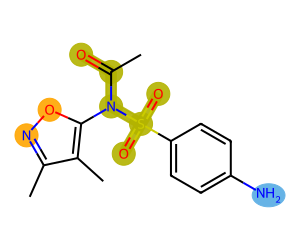

In [29]:
if __name__ == "__main__" or True:

    smiles = "CC(=O)N(C1=C(C)C(C)=NO1)S(=O)(=O)C1=CC=C(N)C=C1" #COC(=O)CCCC(=O)Nc1cccc(Cl)c1

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print("Invalid SMILES")
    else:
        # ============================
        # 1. Extract functional groups and draw whole molecule
        # ============================
        img_data, fgs, psmis, fg_mols = get_dec_fgs(mol, verbose=True)

        print("\nFunctional groups detected:")
        for i, psmi in enumerate(psmis):
            print(f"  FG {i+1}: {psmi}")

        # Save full molecule highlight image at 300 DPI
        img = PILImage.open(io.BytesIO(img_data))
        img.save("Mol_FG_highres_300dpi.png", dpi=(300, 300))
        display(img)

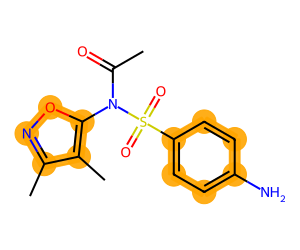

In [31]:
# Continue from previous cell (mol already defined)
if mol is not None:
    # ============================
    # 2. Highlight all rings (atoms and bonds)
    # ============================
    rings = Chem.GetSymmSSSR(mol)
    if not rings:
        print("No rings in molecule.")
    else:
        all_ring_atoms = set()
        ring_bond_indices = set()
        for ring in rings:
            ring_atoms = list(ring)
            all_ring_atoms.update(ring_atoms)
            # Collect bonds within the ring
            n = len(ring_atoms)
            for i in range(n):
                a1 = ring_atoms[i]
                a2 = ring_atoms[(i+1) % n]
                bond = mol.GetBondBetweenAtoms(a1, a2)
                if bond is not None:
                    ring_bond_indices.add(bond.GetIdx())
        # Filter out hydrogens (rings contain no hydrogens, but safety)
        all_ring_atoms = [idx for idx in all_ring_atoms if mol.GetAtomWithIdx(idx).GetAtomicNum() != 1]
        orange_color = (1.0, 0.65, 0.0, 0.9)  # matches "har" color in col_mol
        ring_img_data = draw_highlight(mol, all_ring_atoms, orange_color, bond_indices=ring_bond_indices, rad=0.5, lw=2, width=300, height=250)
        ring_img = PILImage.open(io.BytesIO(ring_img_data))
        ring_img.save("Mol_all_rings_300dpi.png", dpi=(300, 300))
        display(ring_img)

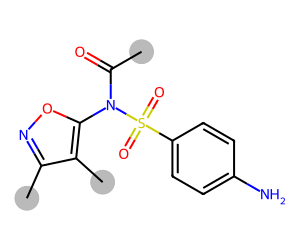

In [33]:
# Continue from previous cells (mol, fgs, rings already defined)
if mol is not None:
    # ============================
    # 3. Highlight non‑core atoms (neither in rings nor in functional groups)
    # ============================
    all_fg_atoms = set().union(*fgs)
    # rings variable already exists from Cell 2; reuse it
    all_ring_atoms = set()
    if rings:
        for ring in rings:
            all_ring_atoms.update(ring)
    non_core_atoms = []
    for atom in mol.GetAtoms():
        if atom.GetAtomicNum() == 1:
            continue
        idx = atom.GetIdx()
        if idx not in all_ring_atoms and idx not in all_fg_atoms:
            non_core_atoms.append(idx)

    if non_core_atoms:
        gray_color = (0.7, 0.7, 0.7, 0.9)
        noncore_img_data = draw_highlight(mol, non_core_atoms, gray_color, rad=0.5, width=300, height=250)
        noncore_img = PILImage.open(io.BytesIO(noncore_img_data))
        noncore_img.save("Mol_noncore_300dpi.png", dpi=(300, 300))
        display(noncore_img)
    else:
        print("No non‑core atoms (all heavy atoms belong to rings or functional groups).")